# Deepfake Protective Evaluation

## Real Deepfake Model Evaluation

This notebook evaluates FaceGuard against a real image-to-image face swapping model using CelebA source-target pairs.

The experiment compares:

1. `source_original + target -> fake without defense`
2. `source_protected + target -> fake with FaceGuard`

Outputs are written to `/content/drive/My Drive/FaceGuard/real_deepfake_eval/` and do not overwrite earlier FaceGuard results.

## 1. Install and Load Deepfake Model

In [1]:
# Colab setup. Re-run only when the runtime is fresh.
%pip -q install insightface onnx onnx2torch onnxruntime-gpu opencv-python-headless scikit-image lpips gdown tqdm pandas matplotlib
%pip install torch==2.6 torchvision --index-url https://download.pytorch.org/whl/cu126

   â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 762.2/762.2 kB 19.2 MB/s eta 0:00:0000:01
   â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 19.1/19.1 MB 99.7 MB/s eta 0:00:00:00:0100:01
   â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 81.0/81.0 kB 9.0 MB/s eta 0:00:00
   â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 220.3/220.3 MB 5.8 MB/s eta 0:00:00:00:0100:01
   â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 53.8/53.8 kB 5.9 MB/s eta 0:00:00
   â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 18.7/18.7 MB 99.1 MB/s eta 0:00:00:00:0100:01
Looking

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive',force_remount=True)
except Exception as exc:
    print('[drive] skipped:', exc)


Mounted at /content/drive


In [12]:
import os
import math
import random
import shutil
import subprocess
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import insightface
from insightface.app import FaceAnalysis
from onnx2torch import convert
from IPython.display import display
import lpips
from PIL import Image, ImageDraw, ImageFont
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from torchvision import transforms
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)

device = cuda


In [13]:
NOW = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')

@dataclass
class RealDeepfakeEvalConfig:
    model_name: str = 'inswapper'
    output_dir: str = f'/content/drive/My Drive/FaceGuard/real_deepfake_eval/{NOW}'
    celeba_zip_path: str = '/content/drive/My Drive/FaceGuard/Datasets/celeba/img_align_celeba.zip'
    celeba_extract_dir: str = '/content/datasets/celeba/img_align'
    celeba_image_dir: str = '/content/datasets/celeba/img_align/img_align_celeba'
    celeba_identity_file: str = '/content/drive/My Drive/FaceGuard/Datasets/celeba/anno/identity_CelebA.txt'
    inswapper_model_path: str = '/content/inswapper_128.onnx'
    inswapper_url: str = 'https://huggingface.co/ezioruan/inswapper_128.onnx/resolve/main/inswapper_128.onnx'
    n_sources: int = 10
    n_targets: int = 10
    max_pairs: int = 100
    random_pair_sampling: bool = True
    deepfake_workers: int = 4
    image_size: int = 224
    epsilon: float = 12 / 255
    epsilon_label: str = '12/255'
    steps: int = 35
    step_ratio: float = 0.125
    success_threshold: float = 0.5
    distance_threshold: float = 0.5
    arcface_input_size: int = 112
    random_start: bool = True
    n_qualitative_grids: int = 10

config = RealDeepfakeEvalConfig()
Path(config.output_dir).mkdir(parents=True, exist_ok=True)
print('Deepfake model name:', config.model_name)
print('Output directory:', config.output_dir)

Deepfake model name: inswapper
Output directory: /content/drive/My Drive/FaceGuard/real_deepfake_eval/20260627_074222


## 2. Prepare Source-Target Pairs

In [14]:
def extract_celeba_if_needed(config):
    image_dir = Path(config.celeba_image_dir)
    if image_dir.exists() and any(image_dir.glob('*.jpg')):
        print('[CelebA] already extracted:', image_dir)
        return str(image_dir)

    zip_path = Path(config.celeba_zip_path)
    if not zip_path.exists():
        raise FileNotFoundError(
            f'CelebA zip not found: {zip_path}. Mount Google Drive or update config.celeba_zip_path.'
        )

    Path(config.celeba_extract_dir).mkdir(parents=True, exist_ok=True)
    print('[CelebA] extracting:', zip_path)
    shutil.unpack_archive(str(zip_path), str(config.celeba_extract_dir))
    if not image_dir.exists():
        raise RuntimeError(f'CelebA extraction completed but image directory is missing: {image_dir}')
    print('[CelebA] extracted:', image_dir)
    return str(image_dir)


def load_celeba_identities(identity_file):
    identity_path = Path(identity_file)
    if not identity_path.exists():
        print('[CelebA] identity file not found; only exact same image paths will be blocked.')
        return {}
    identities = {}
    with identity_path.open('r', encoding='utf-8') as handle:
        for line in handle:
            parts = line.strip().split()
            if len(parts) == 2:
                identities[parts[0]] = parts[1]
    print('[CelebA] loaded identities:', len(identities))
    return identities


def generate_source_target_pairs(source_dir: str, target_dir: str, max_pairs: int):
    source_paths = sorted(Path(source_dir).glob('*.jpg'))
    target_paths = sorted(Path(target_dir).glob('*.jpg'))
    if not source_paths or not target_paths:
        raise RuntimeError(f'No CelebA jpg images found in {source_dir} or {target_dir}')

    identities = load_celeba_identities(config.celeba_identity_file)
    rng = random.Random(SEED)

    def valid_pair(source_path, target_path):
        if source_path == target_path:
            return False
        source_identity = identities.get(source_path.name)
        target_identity = identities.get(target_path.name)
        return not (
            source_identity is not None
            and target_identity is not None
            and source_identity == target_identity
        )

    if config.random_pair_sampling:
        pairs = []
        seen = set()
        max_attempts = max(max_pairs * 100, 10_000)

        for _ in range(max_attempts):
            if len(pairs) >= max_pairs:
                break
            source_path = rng.choice(source_paths)
            target_path = rng.choice(target_paths)
            pair_key = (source_path, target_path)
            if pair_key in seen or not valid_pair(source_path, target_path):
                continue
            seen.add(pair_key)
            pairs.append({'source_path': str(source_path), 'target_path': str(target_path)})

        if not pairs:
            raise RuntimeError('No valid source-target pairs after identity filtering.')
        if len(pairs) < max_pairs:
            print(f'[CelebA] warning: generated only {len(pairs)} valid pairs after {max_attempts} random attempts.')
        return pairs

    if len(source_paths) < config.n_sources + config.n_targets:
        raise RuntimeError(f'Need at least {config.n_sources + config.n_targets} CelebA images, found {len(source_paths)}')

    rng.shuffle(source_paths)
    sources = source_paths[:config.n_sources]
    targets = source_paths[config.n_sources:config.n_sources + config.n_targets]
    pairs = []
    for source_path in sources:
        for target_path in targets:
            if not valid_pair(source_path, target_path):
                continue
            pairs.append({'source_path': str(source_path), 'target_path': str(target_path)})
            if len(pairs) >= max_pairs:
                return pairs
    return pairs


celeba_dir = extract_celeba_if_needed(config)
pairs = generate_source_target_pairs(celeba_dir, celeba_dir, config.max_pairs)
print('source-target pairs:', len(pairs))
pd.DataFrame(pairs).head()

[CelebA] already extracted: /content/datasets/celeba/img_align/img_align_celeba
[CelebA] loaded identities: 202599
source-target pairs: 100


,source_path,target_path
0,/content/datasets/celeba/img_align/img_align_c...,/content/datasets/celeba/img_align/img_align_c...
1,/content/datasets/celeba/img_align/img_align_c...,/content/datasets/celeba/img_align/img_align_c...
2,/content/datasets/celeba/img_align/img_align_c...,/content/datasets/celeba/img_align/img_align_c...
3,/content/datasets/celeba/img_align/img_align_c...,/content/datasets/celeba/img_align/img_align_c...
4,/content/datasets/celeba/img_align/img_align_c...,/content/datasets/celeba/img_align/img_align_c...


## Evaluation Metrics

- `id_retrieval_score_*`: cosine similarity between ArcFace face embeddings of the source image and generated fake. Higher means the fake preserves source identity more strongly.
- `cos_fake_no_defense_fake_faceguard`: cosine similarity between the generated fake without FaceGuard and the generated fake with FaceGuard. Lower means FaceGuard changed the deepfake output identity more strongly.
- `distance_source_fake_*`: cosine distance, computed as `1 - cosine_similarity`. Higher means stronger identity separation.
- `asr_*`: Attack Success Rate, the fraction of pairs where source-to-fake cosine similarity is at least `config.success_threshold`.
- `psr_faceguard`: Protection Success Rate, the fraction of protected pairs where source-to-fake cosine distance is greater than `config.distance_threshold`.
- `psnr`, `ssim`, `lpips`: image-quality comparison between the deepfake generated without FaceGuard and the deepfake generated with FaceGuard. Lower PSNR/SSIM or higher LPIPS means FaceGuard changed the final deepfake output more strongly.
- `psnr_source_protected`, `ssim_source_protected`, `lpips_source_protected`: visual quality of the protected source compared with the original source. These measure perturbation visibility, not deepfake-output change.



## 3. Generate FaceGuard-Protected Sources

In [15]:
to_tensor = transforms.Compose([
    transforms.Resize((config.image_size, config.image_size)),
    transforms.ToTensor(),
])

def load_arcface_identity_model(device=device):
    # providers = ['CUDAExecutionProvider', 'CPUExecutionProvider'] if torch.cuda.is_available() else ['CPUExecutionProvider']
    providers = ['CUDAExecutionProvider', 'CPUExecutionProvider']
    face_app = FaceAnalysis(name='buffalo_l', providers=providers)
    face_app.prepare(ctx_id=0 if torch.cuda.is_available() else -1, det_size=(640, 640))
    arcface_onnx_path = None
    for model in face_app.models.values():
        if getattr(model, 'taskname', None) == 'recognition':
            arcface_onnx_path = model.model_file
            break
    if arcface_onnx_path is None:
        raise RuntimeError('Could not find the buffalo_l ArcFace recognition ONNX model.')
    model = convert(arcface_onnx_path).eval().to(device)
    return model


identity_model = load_arcface_identity_model(device)
lpips_model = lpips.LPIPS(net='alex').eval().to(device)
for param in identity_model.parameters():
    param.requires_grad_(False)
for param in lpips_model.parameters():
    param.requires_grad_(False)


def read_rgb(path, size=None):
    image = Image.open(path).convert('RGB')
    if size is not None:
        image = image.resize((size, size), Image.BICUBIC)
    return np.array(image)


def save_rgb(rgb, path):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    Image.fromarray(np.clip(rgb, 0, 255).astype(np.uint8)).save(path)


def tensor_from_path(path):
    return to_tensor(Image.open(path).convert('RGB')).unsqueeze(0).to(device)


def tensor_to_rgb_uint8(tensor):
    arr = tensor.detach().clamp(0, 1).squeeze(0).permute(1, 2, 0).cpu().numpy()
    return (arr * 255).round().astype(np.uint8)


def arcface_preprocess(x):
    x = F.interpolate(x, size=(config.arcface_input_size, config.arcface_input_size), mode='bilinear', align_corners=False)
    return (x * 255.0 - 127.5) / 127.5


def embedding_from_tensor(x, model=identity_model):
    emb = model(arcface_preprocess(x))
    return F.normalize(emb, p=2, dim=1)


def central_face_mask(batch_size=1, height=224, width=224, device=device):
    mask = torch.zeros((batch_size, 1, height, width), device=device)
    y1, y2 = int(height * 0.18), int(height * 0.86)
    x1, x2 = int(width * 0.20), int(width * 0.80)
    mask[:, :, y1:y2, x1:x2] = 1.0
    return mask


def project_linf_masked(adv, clean, eps, mask):
    delta = torch.clamp(adv - clean, min=-eps, max=eps) * mask
    return (clean + delta).clamp(0, 1)


def protect_faceguard(x, eps=config.epsilon, steps=config.steps, step_ratio=config.step_ratio, mask=None, random_start=config.random_start):
    x = x.detach()
    mask = mask if mask is not None else central_face_mask(x.shape[0], x.shape[2], x.shape[3], x.device)
    alpha = eps * step_ratio
    original_embedding = embedding_from_tensor(x).detach()
    if random_start:
        adv = x + torch.empty_like(x).uniform_(-eps, eps) * mask
        adv = project_linf_masked(adv, x, eps, mask).detach()
    else:
        adv = x.clone().detach()

    for _ in range(steps):
        adv.requires_grad_(True)
        adv_embedding = embedding_from_tensor(adv)
        cosine = F.cosine_similarity(original_embedding, adv_embedding, dim=1).mean()
        grad = torch.autograd.grad(cosine, adv)[0]
        adv = adv.detach() - alpha * grad.sign() * mask
        adv = project_linf_masked(adv, x, eps, mask).detach()
    return adv.detach()


def generate_protected_source(source_path, output_path):
    source_tensor = tensor_from_path(source_path)
    mask = central_face_mask(1, source_tensor.shape[2], source_tensor.shape[3], source_tensor.device)
    protected_tensor = protect_faceguard(source_tensor, mask=mask)
    protected_rgb = tensor_to_rgb_uint8(protected_tensor)
    save_rgb(protected_rgb, output_path)
    return protected_rgb

/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:147: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
Setting up [

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


## 4. Generate Deepfake Outputs

In [16]:
def run_cmd(cmd):
    print('[cmd]', cmd)
    subprocess.check_call(cmd, shell=True)


def ensure_inswapper_checkpoint(config):
    model_path = Path(config.inswapper_model_path)
    if model_path.exists():
        print('[inswapper] checkpoint exists:', model_path)
        return str(model_path)
    if not config.inswapper_url:
        raise FileNotFoundError(f'InSwapper checkpoint missing and no URL configured: {model_path}')
    model_path.parent.mkdir(parents=True, exist_ok=True)
    run_cmd(f'wget -q -O "{model_path}" "{config.inswapper_url}"')
    if not model_path.exists() or model_path.stat().st_size == 0:
        raise RuntimeError(f'Failed to download InSwapper checkpoint: {model_path}')
    return str(model_path)


def load_deepfake_model(model_name: str):
    if model_name.lower() not in {'inswapper', 'insightface-inswapper', 'insightface'}:
        raise ValueError(f'Unsupported deepfake model: {model_name}')

    import insightface
    from insightface.app import FaceAnalysis

    model_path = ensure_inswapper_checkpoint(config)
    providers = ['CUDAExecutionProvider', 'CPUExecutionProvider'] if torch.cuda.is_available() else ['CPUExecutionProvider']
    face_app = FaceAnalysis(name='buffalo_l', providers=providers)
    face_app.prepare(ctx_id=0 if torch.cuda.is_available() else -1, det_size=(640, 640))
    swapper = insightface.model_zoo.get_model(model_path, providers=providers)
    return {'name': 'InsightFace InSwapper', 'face_app': face_app, 'swapper': swapper}


def largest_face(face_app, rgb):
    bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    faces = face_app.get(bgr)
    if not faces:
        return None
    return max(faces, key=lambda face: (face.bbox[2] - face.bbox[0]) * (face.bbox[3] - face.bbox[1]))


def run_deepfake(model, source_path: str, target_path: str, output_path: str):
    source_rgb = read_rgb(source_path)
    target_rgb = read_rgb(target_path)
    source_face = largest_face(model['face_app'], source_rgb)
    target_face = largest_face(model['face_app'], target_rgb)
    if source_face is None:
        return False, 'source_face_not_detected'
    if target_face is None:
        return False, 'target_face_not_detected'

    target_bgr = cv2.cvtColor(target_rgb, cv2.COLOR_RGB2BGR)
    result_bgr = model['swapper'].get(target_bgr.copy(), target_face, source_face, paste_back=True)
    result_rgb = cv2.cvtColor(result_bgr, cv2.COLOR_BGR2RGB)
    save_rgb(result_rgb, output_path)
    return True, 'ok'


if config.deepfake_workers == 1:
    deepfake_model = load_deepfake_model(config.model_name)
    print('Deepfake model name:', deepfake_model['name'])
else:
    deepfake_model = None
    print(f'Deepfake model loading deferred to {config.deepfake_workers} worker threads')

Deepfake model loading deferred to 4 worker threads


## 5. Compute Metrics

In [17]:
def compute_identity_similarity(img1_path: str, img2_path: str, identity_model=identity_model):
    with torch.no_grad():
        x1 = tensor_from_path(img1_path)
        x2 = tensor_from_path(img2_path)
        emb1 = embedding_from_tensor(x1, identity_model)
        emb2 = embedding_from_tensor(x2, identity_model)
        return float(F.cosine_similarity(emb1, emb2, dim=1).item())


def cosine_distance(cosine_similarity):
    return float(1.0 - cosine_similarity)


def compute_lpips_distance(img1_path: str, img2_path: str, perceptual_model=lpips_model):
    with torch.no_grad():
        x1 = tensor_from_path(img1_path) * 2 - 1
        x2 = tensor_from_path(img2_path) * 2 - 1
        return float(perceptual_model(x1, x2).item())


def compute_image_quality(original_path: str, protected_path: str):
    original = read_rgb(original_path, config.image_size)
    protected = read_rgb(protected_path, config.image_size)
    psnr = peak_signal_noise_ratio(original, protected, data_range=255)
    ssim = structural_similarity(original, protected, channel_axis=-1, data_range=255)
    lpips_distance = compute_lpips_distance(original_path, protected_path)
    return float(psnr), float(ssim), float(lpips_distance)


def safe_percent_drop(drop, baseline):
    if baseline is None or abs(baseline) < 1e-8:
        return np.nan
    return float(drop / abs(baseline) * 100)

## 6. Save CSV Results

In [18]:
def summarize_results(per_pair_df, config, deepfake_model_name):
    ok = per_pair_df[per_pair_df['status'].eq('ok')].copy()
    if ok.empty:
        return pd.DataFrame(columns=[
            'deepfake_model', 'method', 'epsilon', 'num_pairs',
            'source_fake_similarity_mean', 'source_fake_similarity_std',
            'source_fake_distance_mean', 'source_fake_distance_std',
            'target_fake_similarity_mean', 'target_fake_similarity_std',
            'deepfake_output_similarity_mean', 'deepfake_output_similarity_std',
            'deepfake_output_distance_mean', 'deepfake_output_distance_std',
            'attack_success_rate', 'protection_success_rate', 'identity_drop_mean', 'identity_drop_percent',
            'psnr', 'ssim', 'lpips', 'psnr_source_protected', 'ssim_source_protected', 'lpips_source_protected'
        ])

    no_defense = {
        'deepfake_model': deepfake_model_name,
        'method': 'No Defense',
        'epsilon': '-',
        'num_pairs': len(ok),
        'source_fake_similarity_mean': ok['cos_source_fake_no_defense'].mean(),
        'source_fake_similarity_std': ok['cos_source_fake_no_defense'].std(ddof=0),
        'source_fake_distance_mean': ok['distance_source_fake_no_defense'].mean(),
        'source_fake_distance_std': ok['distance_source_fake_no_defense'].std(ddof=0),
        'target_fake_similarity_mean': ok['cos_target_fake_no_defense'].mean(),
        'target_fake_similarity_std': ok['cos_target_fake_no_defense'].std(ddof=0),
        'deepfake_output_similarity_mean': np.nan,
        'deepfake_output_similarity_std': np.nan,
        'deepfake_output_distance_mean': np.nan,
        'deepfake_output_distance_std': np.nan,
        'attack_success_rate': ok['asr_no_defense'].mean(),
        'protection_success_rate': np.nan,
        'identity_drop_mean': np.nan,
        'identity_drop_percent': np.nan,
        'psnr': np.nan,
        'ssim': np.nan,
        'lpips': np.nan,
        'psnr_source_protected': np.nan,
        'ssim_source_protected': np.nan,
        'lpips_source_protected': np.nan,
    }
    faceguard = {
        'deepfake_model': deepfake_model_name,
        'method': 'FaceGuard',
        'epsilon': config.epsilon_label,
        'num_pairs': len(ok),
        'source_fake_similarity_mean': ok['cos_source_fake_faceguard'].mean(),
        'source_fake_similarity_std': ok['cos_source_fake_faceguard'].std(ddof=0),
        'source_fake_distance_mean': ok['distance_source_fake_faceguard'].mean(),
        'source_fake_distance_std': ok['distance_source_fake_faceguard'].std(ddof=0),
        'target_fake_similarity_mean': ok['cos_target_fake_faceguard'].mean(),
        'target_fake_similarity_std': ok['cos_target_fake_faceguard'].std(ddof=0),
        'deepfake_output_similarity_mean': ok['cos_fake_no_defense_fake_faceguard'].mean(),
        'deepfake_output_similarity_std': ok['cos_fake_no_defense_fake_faceguard'].std(ddof=0),
        'deepfake_output_distance_mean': ok['distance_fake_no_defense_fake_faceguard'].mean(),
        'deepfake_output_distance_std': ok['distance_fake_no_defense_fake_faceguard'].std(ddof=0),
        'attack_success_rate': ok['asr_faceguard'].mean(),
        'protection_success_rate': ok['psr_faceguard'].mean(),
        'identity_drop_mean': ok['identity_drop'].mean(),
        'identity_drop_percent': ok['identity_drop_percent'].mean(),
        'psnr': ok['psnr'].mean(),
        'ssim': ok['ssim'].mean(),
        'lpips': ok['lpips'].mean(),
        'psnr_source_protected': ok['psnr_source_protected'].mean(),
        'ssim_source_protected': ok['ssim_source_protected'].mean(),
        'lpips_source_protected': ok['lpips_source_protected'].mean(),
    }
    return pd.DataFrame([no_defense, faceguard])


def _pair_paths(pair_idx, pair, image_dir):
    pair_id = f'pair_{pair_idx:04d}'
    return {
        'pair_id': pair_id,
        'source_original_path': pair['source_path'],
        'target_original_path': pair['target_path'],
        'source_image_path': str(image_dir / f'{pair_id}_source.jpg'),
        'target_image_path': str(image_dir / f'{pair_id}_target.jpg'),
        'protected_source_path': str(image_dir / f'{pair_id}_source_protected.png'),
        'fake_no_defense_path': str(image_dir / f'{pair_id}_fake_no_defense.png'),
        'fake_faceguard_path': str(image_dir / f'{pair_id}_fake_faceguard.png'),
    }


_worker_state = threading.local()
_model_load_lock = threading.Lock()


def _get_worker_model(config):
    if int(getattr(config, 'deepfake_workers', 1)) == 1:
        model = globals().get('deepfake_model')
        if model is not None:
            return model

    model = getattr(_worker_state, 'deepfake_model', None)
    if model is not None:
        return model

    with _model_load_lock:
        model = getattr(_worker_state, 'deepfake_model', None)
        if model is None:
            model = load_deepfake_model(config.model_name)
            _worker_state.deepfake_model = model
        return model


def _run_deepfake_pair(paths, config):
    model = _get_worker_model(config)
    ok_clean, clean_status = run_deepfake(
        model,
        paths['source_image_path'],
        paths['target_image_path'],
        paths['fake_no_defense_path'],
    )
    ok_protected, protected_status = run_deepfake(
        model,
        paths['protected_source_path'],
        paths['target_image_path'],
        paths['fake_faceguard_path'],
    )
    status = 'ok' if ok_clean and ok_protected else f'clean={clean_status}; protected={protected_status}'
    return {**paths, 'status': status}


def _metrics_for_pair(result, config):
    cos_source_fake_no_defense = compute_identity_similarity(result['source_image_path'], result['fake_no_defense_path'])
    cos_source_fake_faceguard = compute_identity_similarity(result['source_image_path'], result['fake_faceguard_path'])
    cos_target_fake_no_defense = compute_identity_similarity(result['target_image_path'], result['fake_no_defense_path'])
    cos_target_fake_faceguard = compute_identity_similarity(result['target_image_path'], result['fake_faceguard_path'])
    cos_fake_no_defense_fake_faceguard = compute_identity_similarity(result['fake_no_defense_path'], result['fake_faceguard_path'])
    distance_source_fake_no_defense = cosine_distance(cos_source_fake_no_defense)
    distance_source_fake_faceguard = cosine_distance(cos_source_fake_faceguard)
    distance_target_fake_no_defense = cosine_distance(cos_target_fake_no_defense)
    distance_target_fake_faceguard = cosine_distance(cos_target_fake_faceguard)
    distance_fake_no_defense_fake_faceguard = cosine_distance(cos_fake_no_defense_fake_faceguard)
    identity_drop = cos_source_fake_no_defense - cos_source_fake_faceguard
    asr_no_defense = cos_source_fake_no_defense >= config.success_threshold
    asr_faceguard = cos_source_fake_faceguard >= config.success_threshold
    psr_faceguard = distance_source_fake_faceguard > config.distance_threshold
    psnr, ssim, lpips_distance = compute_image_quality(result['fake_no_defense_path'], result['fake_faceguard_path'])
    psnr_source_protected, ssim_source_protected, lpips_source_protected = compute_image_quality(result['source_image_path'], result['protected_source_path'])

    return {
        'pair_id': result['pair_id'],
        'source_image_path': result['source_image_path'],
        'target_image_path': result['target_image_path'],
        'protected_source_path': result['protected_source_path'],
        'fake_no_defense_path': result['fake_no_defense_path'],
        'fake_faceguard_path': result['fake_faceguard_path'],
        'status': result['status'],
        'cos_source_fake_no_defense': cos_source_fake_no_defense,
        'cos_source_fake_faceguard': cos_source_fake_faceguard,
        'id_retrieval_score_no_defense': cos_source_fake_no_defense,
        'id_retrieval_score_faceguard': cos_source_fake_faceguard,
        'distance_source_fake_no_defense': distance_source_fake_no_defense,
        'distance_source_fake_faceguard': distance_source_fake_faceguard,
        'cos_target_fake_no_defense': cos_target_fake_no_defense,
        'cos_target_fake_faceguard': cos_target_fake_faceguard,
        'distance_target_fake_no_defense': distance_target_fake_no_defense,
        'distance_target_fake_faceguard': distance_target_fake_faceguard,
        'cos_fake_no_defense_fake_faceguard': cos_fake_no_defense_fake_faceguard,
        'distance_fake_no_defense_fake_faceguard': distance_fake_no_defense_fake_faceguard,
        'identity_drop': identity_drop,
        'identity_drop_percent': safe_percent_drop(identity_drop, cos_source_fake_no_defense),
        'success_no_defense': asr_no_defense,
        'success_faceguard': asr_faceguard,
        'asr_no_defense': asr_no_defense,
        'asr_faceguard': asr_faceguard,
        'psr_faceguard': psr_faceguard,
        'psnr': psnr,
        'ssim': ssim,
        'lpips': lpips_distance,
        'psnr_source_protected': psnr_source_protected,
        'ssim_source_protected': ssim_source_protected,
        'lpips_source_protected': lpips_source_protected,
    }


def run_real_deepfake_evaluation(config):
    output_dir = Path(config.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    image_dir = output_dir / 'images'
    image_dir.mkdir(parents=True, exist_ok=True)

    source_target_pairs = generate_source_target_pairs(config.celeba_image_dir, config.celeba_image_dir, config.max_pairs)
    workers = max(1, int(getattr(config, 'deepfake_workers', 1)))
    prepared = []
    rows = []
    failures = []

    print(f'[pairs] random_pair_sampling={config.random_pair_sampling}; pairs={len(source_target_pairs)}')
    print(f'[parallel] deepfake_workers={workers}')

    for pair_idx, pair in enumerate(tqdm(source_target_pairs, desc='Prepare protected sources'), start=1):
        paths = _pair_paths(pair_idx, pair, image_dir)
        save_rgb(read_rgb(paths['source_original_path']), paths['source_image_path'])
        save_rgb(read_rgb(paths['target_original_path']), paths['target_image_path'])
        generate_protected_source(paths['source_image_path'], paths['protected_source_path'])
        prepared.append(paths)

    if workers == 1:
        deepfake_results = [_run_deepfake_pair(paths, config) for paths in tqdm(prepared, desc='Real deepfake evaluation')]
    else:
        deepfake_results = []
        with ThreadPoolExecutor(max_workers=workers) as executor:
            futures = [executor.submit(_run_deepfake_pair, paths, config) for paths in prepared]
            for future in tqdm(as_completed(futures), total=len(futures), desc='Real deepfake evaluation'):
                deepfake_results.append(future.result())
        deepfake_results.sort(key=lambda row: row['pair_id'])

    deepfake_model_name = 'InsightFace InSwapper'
    for result in tqdm(deepfake_results, desc='Compute metrics'):
        if result['status'] != 'ok':
            failures.append({
                'pair_id': result['pair_id'],
                'source_image_path': result['source_image_path'],
                'target_image_path': result['target_image_path'],
                'status': result['status'],
            })
            continue
        rows.append(_metrics_for_pair(result, config))

    per_pair_df = pd.DataFrame(rows)
    failed_df = pd.DataFrame(failures)
    summary_df = summarize_results(per_pair_df, config, deepfake_model_name)

    per_pair_path = output_dir / 'metrics_per_pair.csv'
    summary_path = output_dir / 'metrics_summary.csv'
    failed_path = output_dir / 'failed_pairs.csv'
    per_pair_df.to_csv(per_pair_path, index=False)
    summary_df.to_csv(summary_path, index=False)
    failed_df.to_csv(failed_path, index=False)
    print('[saved]', per_pair_path)
    print('[saved]', summary_path)
    print('[saved]', failed_path)
    return per_pair_df, summary_df, failed_df


per_pair_df, summary_df, failed_df = run_real_deepfake_evaluation(config)
display(summary_df)
display(per_pair_df.head())

[CelebA] loaded identities: 202599
[pairs] random_pair_sampling=True; pairs=100
[parallel] deepfake_workers=4


Prepare protected sources:   0%|          | 0/100 [00:00<?, ?it/s]

[inswapper] checkpoint exists: /content/inswapper_128.onnx


Real deepfake evaluation:   0%|          | 0/100 [00:00<?, ?it/s]

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
Applied prov

Compute metrics:   0%|          | 0/100 [00:00<?, ?it/s]

[saved] /content/drive/My Drive/FaceGuard/real_deepfake_eval/20260627_074222/metrics_per_pair.csv
[saved] /content/drive/My Drive/FaceGuard/real_deepfake_eval/20260627_074222/metrics_summary.csv
[saved] /content/drive/My Drive/FaceGuard/real_deepfake_eval/20260627_074222/failed_pairs.csv


,deepfake_model,method,epsilon,num_pairs,source_fake_similarity_mean,source_fake_similarity_std,source_fake_distance_mean,source_fake_distance_std,target_fake_similarity_mean,target_fake_similarity_std,...,attack_success_rate,protection_success_rate,identity_drop_mean,identity_drop_percent,psnr,ssim,lpips,psnr_source_protected,ssim_source_protected,lpips_source_protected
0,InsightFace InSwapper,No Defense,-,99,0.469914,0.109272,0.530086,0.109272,0.292942,0.136105,...,0.404040,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,InsightFace InSwapper,FaceGuard,12/255,99,0.149340,0.126685,0.850660,0.126685,0.297474,0.122896,...,0.010101,0.989899,0.320573,67.452215,32.812606,0.963713,0.016815,33.009066,0.905515,0.092851


,pair_id,source_image_path,target_image_path,protected_source_path,fake_no_defense_path,fake_faceguard_path,status,cos_source_fake_no_defense,cos_source_fake_faceguard,id_retrieval_score_no_defense,...,success_faceguard,asr_no_defense,asr_faceguard,psr_faceguard,psnr,ssim,lpips,psnr_source_protected,ssim_source_protected,lpips_source_protected
0,pair_0001,/content/drive/My Drive/FaceGuard/real_deepfak...,/content/drive/My Drive/FaceGuard/real_deepfak...,/content/drive/My Drive/FaceGuard/real_deepfak...,/content/drive/My Drive/FaceGuard/real_deepfak...,/content/drive/My Drive/FaceGuard/real_deepfak...,ok,0.495556,-0.061308,0.495556,...,False,False,False,True,31.785226,0.950986,0.026378,32.400874,0.914946,0.050464
1,pair_0002,/content/drive/My Drive/FaceGuard/real_deepfak...,/content/drive/My Drive/FaceGuard/real_deepfak...,/content/drive/My Drive/FaceGuard/real_deepfak...,/content/drive/My Drive/FaceGuard/real_deepfak...,/content/drive/My Drive/FaceGuard/real_deepfak...,ok,0.386733,0.371394,0.386733,...,False,False,False,True,34.786482,0.969813,0.012800,33.049565,0.917058,0.093884
2,pair_0003,/content/drive/My Drive/FaceGuard/real_deepfak...,/content/drive/My Drive/FaceGuard/real_deepfak...,/content/drive/My Drive/FaceGuard/real_deepfak...,/content/drive/My Drive/FaceGuard/real_deepfak...,/content/drive/My Drive/FaceGuard/real_deepfak...,ok,0.522318,0.233018,0.522318,...,False,True,False,True,28.007794,0.954087,0.023840,33.022236,0.909248,0.056047
3,pair_0004,/content/drive/My Drive/FaceGuard/real_deepfak...,/content/drive/My Drive/FaceGuard/real_deepfak...,/content/drive/My Drive/FaceGuard/real_deepfak...,/content/drive/My Drive/FaceGuard/real_deepfak...,/content/drive/My Drive/FaceGuard/real_deepfak...,ok,0.492801,0.186559,0.492801,...,False,False,False,True,34.884742,0.967346,0.019380,33.153080,0.903991,0.100113
4,pair_0005,/content/drive/My Drive/FaceGuard/real_deepfak...,/content/drive/My Drive/FaceGuard/real_deepfak...,/content/drive/My Drive/FaceGuard/real_deepfak...,/content/drive/My Drive/FaceGuard/real_deepfak...,/content/drive/My Drive/FaceGuard/real_deepfak...,ok,0.231850,-0.080592,0.231850,...,False,False,False,True,32.445836,0.964347,0.008587,32.839929,0.899541,0.099188


## 7. Metric Preview Figure

[saved] /content/drive/My Drive/FaceGuard/real_deepfake_eval/20260627_074222/metric_preview_figure.png


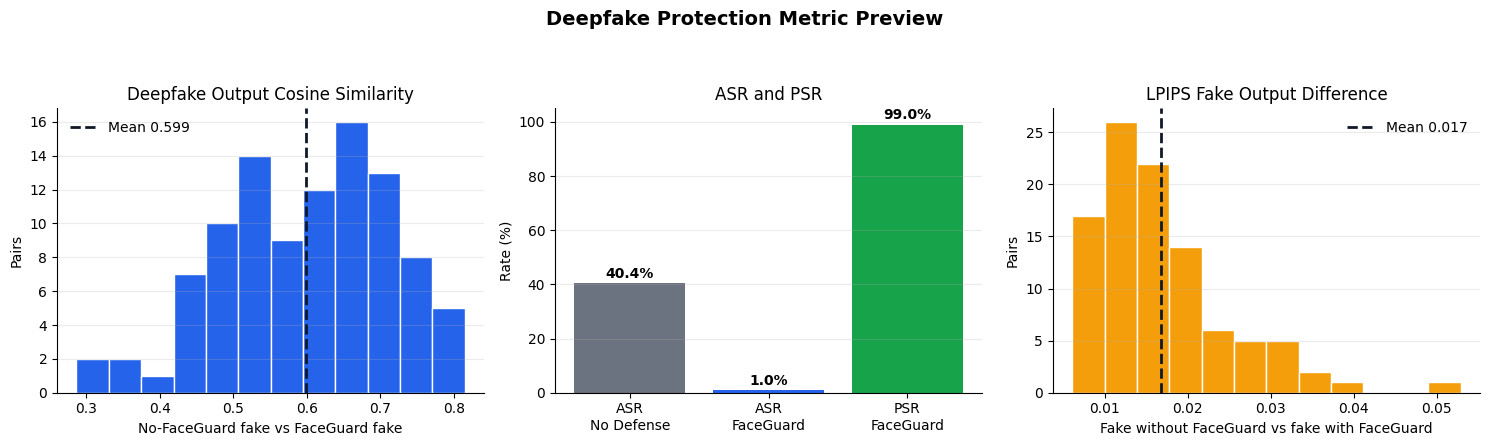

In [19]:
def create_metric_preview_figure(per_pair_df, output_path):
    ok = per_pair_df[per_pair_df['status'].eq('ok')].copy()
    if ok.empty:
        raise ValueError('No successful pairs available for metric preview figure')
    if 'cos_fake_no_defense_fake_faceguard' not in ok.columns:
        ok['cos_fake_no_defense_fake_faceguard'] = ok.apply(
            lambda row: compute_identity_similarity(row['fake_no_defense_path'], row['fake_faceguard_path']),
            axis=1,
        )

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    fig.suptitle('Deepfake Protection Metric Preview', fontsize=14, fontweight='bold')

    output_cosine = ok['cos_fake_no_defense_fake_faceguard'].dropna()
    axes[0].set_title('Deepfake Output Cosine Similarity')
    axes[0].set_ylabel('Pairs')
    axes[0].set_xlabel('No-FaceGuard fake vs FaceGuard fake')
    if len(output_cosine):
        axes[0].hist(output_cosine, bins=min(12, max(3, len(output_cosine))), color='#2563eb', edgecolor='white')
        axes[0].axvline(output_cosine.mean(), color='#111827', linestyle='--', linewidth=2, label=f'Mean {output_cosine.mean():.3f}')
        axes[0].legend(frameon=False)
    else:
        axes[0].text(0.5, 0.5, 'No output cosine values', ha='center', va='center', transform=axes[0].transAxes)

    rate_labels = ['ASR\nNo Defense', 'ASR\nFaceGuard', 'PSR\nFaceGuard']
    rate_values = [
        ok['asr_no_defense'].mean() * 100,
        ok['asr_faceguard'].mean() * 100,
        ok['psr_faceguard'].mean() * 100,
    ]
    axes[1].bar(rate_labels, rate_values, color=['#6b7280', '#2563eb', '#16a34a'])
    axes[1].set_title('ASR and PSR')
    axes[1].set_ylabel('Rate (%)')
    axes[1].set_ylim(0, 105)
    for idx, value in enumerate(rate_values):
        axes[1].text(idx, value + 2, f'{value:.1f}%', ha='center', fontweight='bold')

    lpips_values = ok['lpips'].dropna()
    axes[2].set_title('LPIPS Fake Output Difference')
    axes[2].set_xlabel('Fake without FaceGuard vs fake with FaceGuard')
    axes[2].set_ylabel('Pairs')
    if len(lpips_values):
        axes[2].hist(lpips_values, bins=min(12, max(3, len(lpips_values))), color='#f59e0b', edgecolor='white')
        axes[2].axvline(lpips_values.mean(), color='#111827', linestyle='--', linewidth=2, label=f'Mean {lpips_values.mean():.3f}')
        axes[2].legend(frameon=False)
    else:
        axes[2].text(0.5, 0.5, 'No LPIPS values', ha='center', va='center', transform=axes[2].transAxes)

    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', alpha=0.25)

    fig.tight_layout(rect=(0, 0, 1, 0.92))
    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=200, bbox_inches='tight')
    print('[saved]', output_path)
    return fig


metric_preview_path = Path(config.output_dir) / 'metric_preview_figure.png'
create_metric_preview_figure(per_pair_df, metric_preview_path)
plt.show()

## 8. Visualize Qualitative Examples

[saved] /content/drive/My Drive/FaceGuard/real_deepfake_eval/20260627_074222/qualitative_grid_001.png
[saved] /content/drive/My Drive/FaceGuard/real_deepfake_eval/20260627_074222/qualitative_grid_002.png
[saved] /content/drive/My Drive/FaceGuard/real_deepfake_eval/20260627_074222/qualitative_grid_003.png
[saved] /content/drive/My Drive/FaceGuard/real_deepfake_eval/20260627_074222/qualitative_grid_004.png
[saved] /content/drive/My Drive/FaceGuard/real_deepfake_eval/20260627_074222/qualitative_grid_005.png
[saved] /content/drive/My Drive/FaceGuard/real_deepfake_eval/20260627_074222/qualitative_grid_006.png
[saved] /content/drive/My Drive/FaceGuard/real_deepfake_eval/20260627_074222/qualitative_grid_007.png
[saved] /content/drive/My Drive/FaceGuard/real_deepfake_eval/20260627_074222/qualitative_grid_008.png
[saved] /content/drive/My Drive/FaceGuard/real_deepfake_eval/20260627_074222/qualitative_grid_009.png
[saved] /content/drive/My Drive/FaceGuard/real_deepfake_eval/20260627_074222/quali

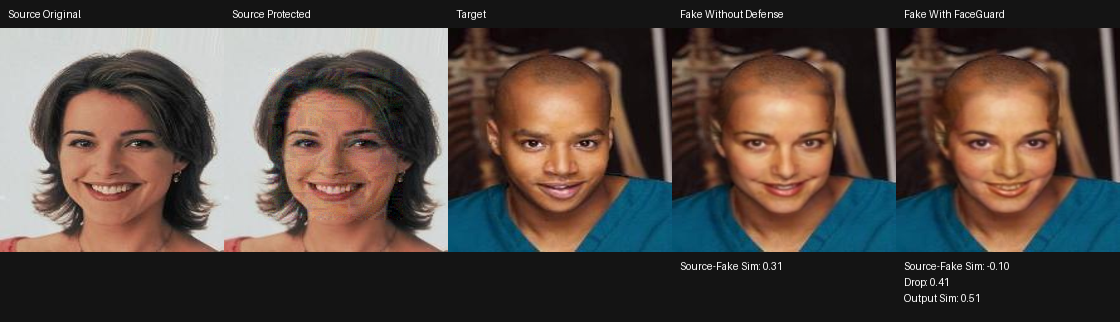

In [20]:
def draw_label(draw, x, y, text, font, fill=(255, 255, 255)):
    lines = str(text).split('\n')
    for line in lines:
        draw.text((x, y), line, font=font, fill=fill)
        y += 16


def create_qualitative_grid(rows, output_path: str):
    if isinstance(rows, pd.DataFrame):
        rows = rows.to_dict('records')
    if not rows:
        raise ValueError('No rows available for qualitative grid')

    columns = [
        ('source_image_path', 'Source Original'),
        ('protected_source_path', 'Source Protected'),
        ('target_image_path', 'Target'),
        ('fake_no_defense_path', 'Fake Without Defense'),
        ('fake_faceguard_path', 'Fake With FaceGuard'),
    ]
    tile = 224
    label_h = 70
    header_h = 28
    grid_w = tile * len(columns)
    grid_h = header_h + (tile + label_h) * len(rows)
    canvas = Image.new('RGB', (grid_w, grid_h), (20, 20, 20))
    draw = ImageDraw.Draw(canvas)
    font = ImageFont.load_default()

    for col_idx, (_, title) in enumerate(columns):
        draw.text((col_idx * tile + 8, 8), title, font=font, fill=(255, 255, 255))

    for row_idx, row in enumerate(rows):
        y0 = header_h + row_idx * (tile + label_h)
        for col_idx, (path_key, _) in enumerate(columns):
            x0 = col_idx * tile
            image = Image.open(row[path_key]).convert('RGB').resize((tile, tile), Image.BICUBIC)
            canvas.paste(image, (x0, y0))
        output_sim = row.get('cos_fake_no_defense_fake_faceguard')
        output_sim_label = '' if pd.isna(output_sim) else f"\nOutput Sim: {output_sim:.2f}"
        clean_label = f"Source-Fake Sim: {row['cos_source_fake_no_defense']:.2f}"
        protected_label = (
            f"Source-Fake Sim: {row['cos_source_fake_faceguard']:.2f}\n"
            f"Drop: {row['identity_drop']:.2f}{output_sim_label}"
        )
        draw_label(draw, 3 * tile + 8, y0 + tile + 8, clean_label, font)
        draw_label(draw, 4 * tile + 8, y0 + tile + 8, protected_label, font)

    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    canvas.save(output_path)
    return output_path


ok_df = per_pair_df[per_pair_df['status'].eq('ok')].copy()
if len(ok_df):
    selected = ok_df.sample(n=min(config.n_qualitative_grids, len(ok_df)))
    for idx, (_, row) in enumerate(selected.iterrows(), start=1):
        grid_path = Path(config.output_dir) / f'qualitative_grid_{idx:03d}.png'
        create_qualitative_grid([row.to_dict()], str(grid_path))
        print('[saved]', grid_path)
    display(Image.open(Path(config.output_dir) / 'qualitative_grid_001.png'))
else:
    print('No successful pairs available for qualitative grid generation.')

## 9. Summary and Interpretation

In [21]:
def print_required_summary(per_pair_df, config, model_name):
    ok = per_pair_df[per_pair_df['status'].eq('ok')].copy()
    print('Deepfake model name:', model_name)
    print('Number of successful source-target pairs:', len(ok))
    if ok.empty:
        print('No successful source-target pairs. Check failed_pairs.csv for face detection/model errors.')
        return
    if 'cos_fake_no_defense_fake_faceguard' not in ok.columns:
        ok['cos_fake_no_defense_fake_faceguard'] = ok.apply(
            lambda row: compute_identity_similarity(row['fake_no_defense_path'], row['fake_faceguard_path']),
            axis=1,
        )

    success_no_defense = ok['asr_no_defense'].mean()
    success_faceguard = ok['asr_faceguard'].mean()
    protection_success = ok['psr_faceguard'].mean()
    attack_reduction = np.nan
    if success_no_defense > 0:
        attack_reduction = (success_no_defense - success_faceguard) / success_no_defense * 100

    print('Cosine similarity threshold for ASR:', config.success_threshold)
    print('Cosine distance threshold for PSR:', config.distance_threshold)
    print('Mean ID retrieval score without defense:', ok['id_retrieval_score_no_defense'].mean())
    print('Mean ID retrieval score with FaceGuard:', ok['id_retrieval_score_faceguard'].mean())
    print('Mean deepfake-output cosine similarity (no FaceGuard fake vs FaceGuard fake):', ok['cos_fake_no_defense_fake_faceguard'].mean())
    print('Mean source-fake cosine distance without defense:', ok['distance_source_fake_no_defense'].mean())
    print('Mean source-fake cosine distance with FaceGuard:', ok['distance_source_fake_faceguard'].mean())
    print('Mean identity drop:', ok['identity_drop'].mean())
    print('Attack Success Rate without defense:', success_no_defense)
    print('Attack Success Rate with FaceGuard:', success_faceguard)
    print('Protection Success Rate with FaceGuard:', protection_success)
    print('Attack reduction rate:', attack_reduction)
    print('Mean PSNR between fake outputs:', ok['psnr'].mean())
    print('Mean SSIM between fake outputs:', ok['ssim'].mean())
    print('Mean LPIPS between fake outputs:', ok['lpips'].mean())
    print('Mean PSNR of protected source images:', ok['psnr_source_protected'].mean())
    print('Mean SSIM of protected source images:', ok['ssim_source_protected'].mean())
    print('Mean LPIPS of protected source images:', ok['lpips_source_protected'].mean())

print_required_summary(per_pair_df, config, "HEHE")

Deepfake model name: HEHE
Number of successful source-target pairs: 99
Cosine similarity threshold for ASR: 0.5
Cosine distance threshold for PSR: 0.5
Mean ID retrieval score without defense: 0.46991370844118524
Mean ID retrieval score with FaceGuard: 0.1493402635960868
Mean deepfake-output cosine similarity (no FaceGuard fake vs FaceGuard fake): 0.5992399309620713
Mean source-fake cosine distance without defense: 0.5300862915588148
Mean source-fake cosine distance with FaceGuard: 0.8506597364039132
Mean identity drop: 0.3205734448450984
Attack Success Rate without defense: 0.40404040404040403
Attack Success Rate with FaceGuard: 0.010101010101010102
Protection Success Rate with FaceGuard: 0.98989898989899
Attack reduction rate: 97.5
Mean PSNR between fake outputs: 32.81260625561121
Mean SSIM between fake outputs: 0.9637130222033515
Mean LPIPS between fake outputs: 0.0168149493578257
Mean PSNR of protected source images: 33.00906593575972
Mean SSIM of protected source images: 0.90551454

The real deepfake evaluation shows whether the selected face-swapping model preserves the source identity when the original source image is used and whether FaceGuard-protected source images reduce source-to-fake identity similarity. A lower source-fake similarity and lower deepfake success rate after protection indicate that FaceGuard disrupts identity transfer beyond embedding-space evaluation.

If FaceGuard does not substantially reduce source identity transfer for this model, rerun with `epsilon = 16 / 255`, add transformation-aware optimization, or evaluate another model such as SimSwap or FaceFusion.